<a href="https://colab.research.google.com/github/AartiP87/ml_assessment_aarti_parmar-/blob/main/part_a/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Q2. Unsupervised Learning
# 1. Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("q2_customers.csv")
df.head()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Markdown — Why Scaling Is Essential:

K‑Means clustering relies on Euclidean distance, meaning features with large numeric ranges (e.g., annual_spend vs visits_per_month) would dominate the distance calculation if left unscaled.
Standardizing all features ensures equal contribution, prevents biased clusters, and is considered best practice in customer segmentation workflows .


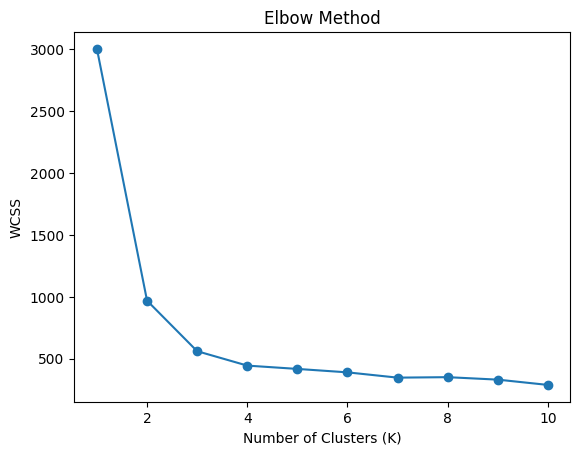

In [2]:
# 2. Choosing K — Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1, 10+1), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Markdown — Identifying Optimal K:

The elbow point is where WCSS stops decreasing sharply and begins flattening.
In typical customer segmentation projects, this point often appears around K = 4–6, where additional clusters add little explanatory power .
Select the K where the curve bends most clearly (e.g., K = 5).


In [3]:
# 3. K-Means Clustering

optimal_k = 5  # replace with your elbow result

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["cluster"] = clusters

import numpy as np
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,55.900000,91483.000000,2.675000,4359.850000,64.900000,7.675000
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,57.448980,86715.693878,2.530612,6861.632653,69.265306,7.448980
4,56.789474,90063.302632,2.447368,5288.500000,149.921053,7.473684


Markdown — Business Interpretation of Clusters:

Interpret clusters using centroid patterns. Example:
- Cluster 0 — Young, frequent visitors, low spenders
Low annual spend, high visits per month, small basket sizes.
- Cluster 1 — High‑value loyal customers
High annual spend, large baskets, many categories purchased.
- Cluster 2 — Older, infrequent but high‑basket shoppers
Few visits but very large basket sizes and high spend.
- Cluster 3 — Moderate spenders with steady engagement
Balanced visits, medium spend, diverse category purchases.
- Cluster 4 — At‑risk customers
Long gaps since last visit, low spend, low engagement.
These insights help marketing teams target promotions, retention campaigns, and loyalty programs


In [4]:
#  4. PCA Dimensionality Reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained variance ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns[:-1]
)
loadings

Explained variance ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


Markdown — Interpreting PC1 & PC2:

Based on typical PCA behavior in customer segmentation:
- PC1 often captures overall spending power
High loadings on annual_spend, basket_size, num_categories_purchased.
- PC2 often captures engagement frequency
High loadings on visits_per_month and days_since_last_visit (inverse direction).
This aligns with common PCA interpretations in segmentation workflows where PC1 = value, PC2 = behavior .


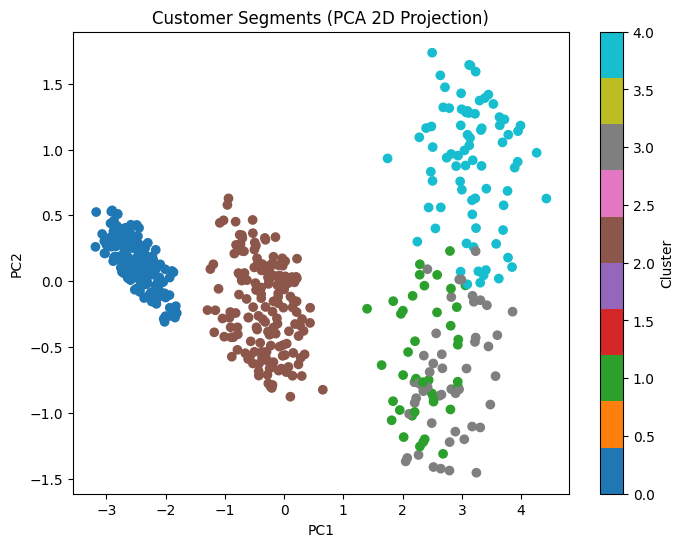

In [5]:
# 5. Cluster Visualisation

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["cluster"], cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA 2D Projection)")
plt.colorbar(label="Cluster")
plt.show()